In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

df_raw = pd.read_csv("../data/intraday_prices.csv", parse_dates=["timestamp"])


# Exploratory Data Analysis

In [53]:
# data quality
time_diffs = df_raw["timestamp"].diff().dropna()
expected_step = pd.Timedelta(minutes=15)
gaps = (time_diffs != expected_step).sum()
missing_values = df_raw.isnull().sum().to_dict()
duplicates = df_raw["timestamp"].duplicated().sum()

print(f"Total observations: {len(df_raw)}")
print(f"Missing values: {missing_values}")
print(f"Duplicate timestamps: {duplicates}")
print(f"Irregular interval gaps: {gaps} (expected step: 15 minutes)")
display(df_raw["price"].describe().to_frame().T.round(2))
df_raw["time_str"] = df_raw["timestamp"].dt.strftime("%H:%M")

Total observations: 8640
Missing values: {'timestamp': 0, 'price': 0}
Duplicate timestamps: 0
Irregular interval gaps: 0 (expected step: 15 minutes)


,count,mean,std,min,25%,50%,75%,max
price,8640.0,63.85,13.02,18.58,55.17,64.75,73.07,101.37


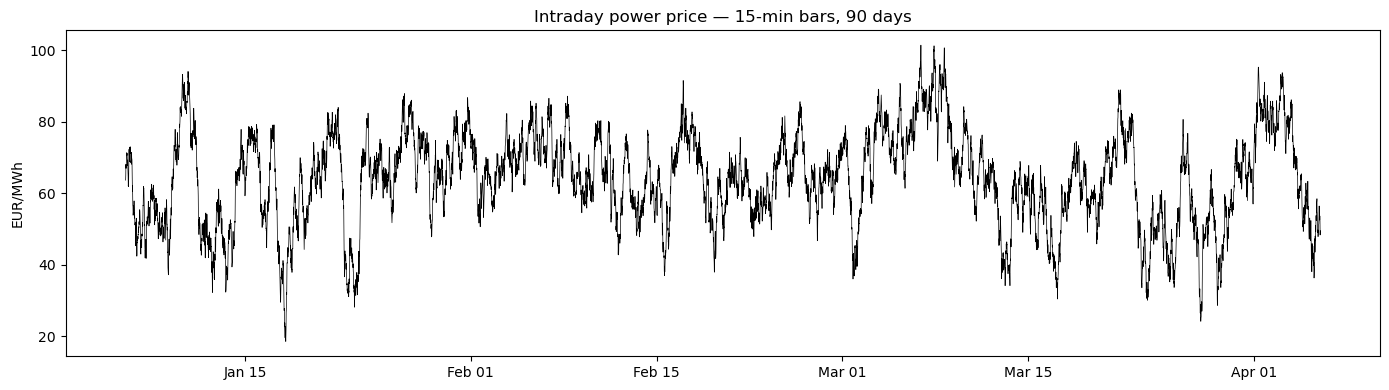

In [54]:
# time series of prices
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df_raw["timestamp"], df_raw["price"], linewidth=0.5, color="black")
ax.set_ylabel("EUR/MWh")
ax.set_title("Intraday power price — 15-min bars, 90 days")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
plt.tight_layout()
plt.show()

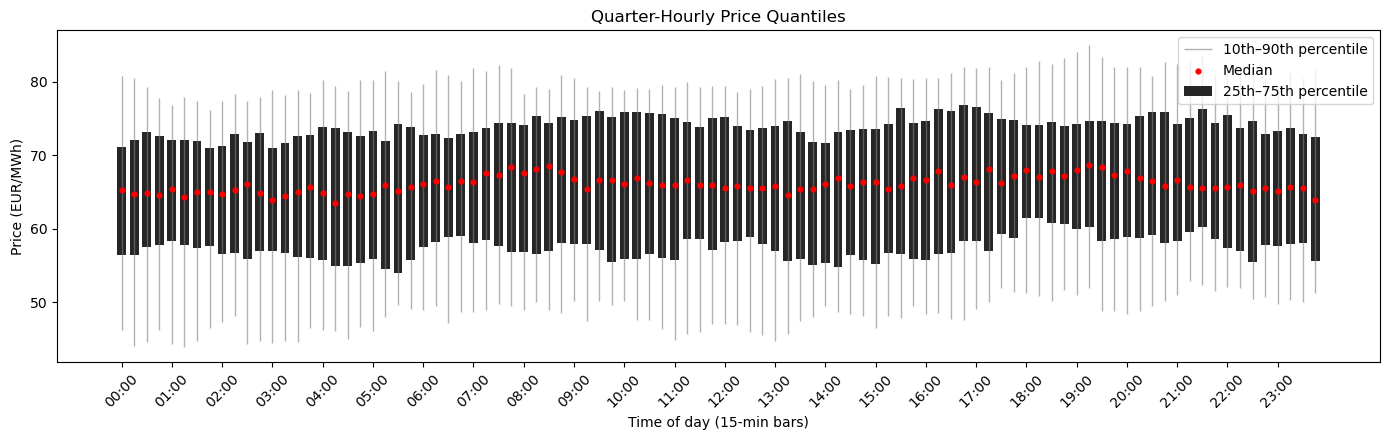

In [55]:
# quantiles for intraday prices
quantiles = df_weekdays.groupby("time_str")["price"].quantile([0.10, 0.25, 0.50, 0.75, 0.90]).unstack()

fig, ax = plt.subplots(figsize=(14, 4.5))
x = np.arange(len(quantiles))

ax.vlines(x, ymin=quantiles[0.10], ymax=quantiles[0.90], color="grey", linewidth=1.0, alpha=0.6, label="10th–90th percentile")
ax.bar(x, quantiles[0.75] - quantiles[0.25], bottom=quantiles[0.25], color="black", width=0.7, alpha=0.85, label="25th–75th percentile")
ax.scatter(x, quantiles[0.50], color="red", s=12, zorder=5, label="Median")

xticks = x[::4]
ax.set_xticks(xticks)
ax.set_xticklabels(quantiles.index[::4], rotation=45)
ax.set_ylabel("Price (EUR/MWh)")
ax.set_xlabel("Time of day (15-min bars)")
ax.set_title("Quarter-Hourly Price Quantiles")
ax.legend()
plt.tight_layout()
plt.show()

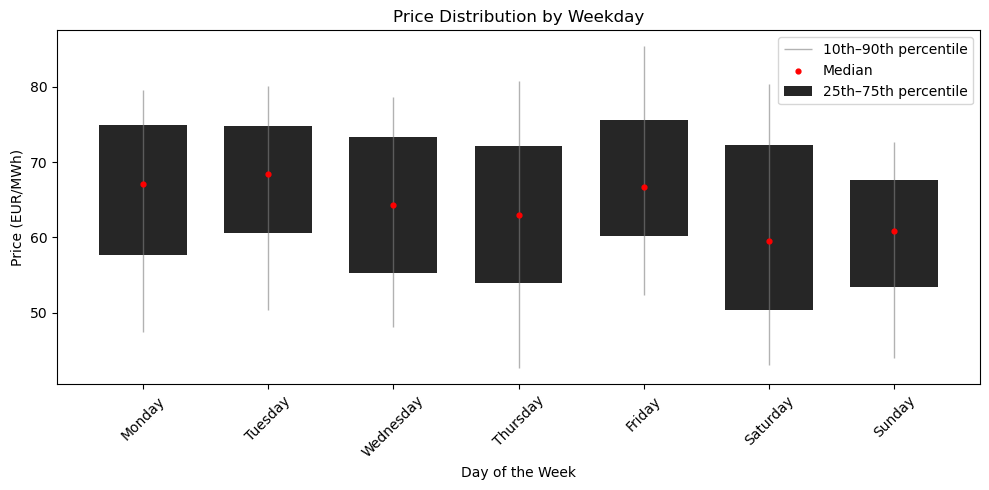

In [69]:
# boxplot of prices by day of week
days_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
df_raw["day_name"] = pd.Categorical(df_raw["timestamp"].dt.day_name(), categories=days_order, ordered=True)

# quantiles for intraday prices
quantiles = df_raw.groupby("day_name", observed=True)["price"].quantile([0.10, 0.25, 0.50, 0.75, 0.90]).unstack()

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(quantiles))

ax.vlines(x, ymin=quantiles[0.10], ymax=quantiles[0.90], color="grey", linewidth=1.0, alpha=0.6, label="10th–90th percentile")
ax.bar(x, quantiles[0.75] - quantiles[0.25], bottom=quantiles[0.25], color="black", width=0.7, alpha=0.85, label="25th–75th percentile")
ax.scatter(x, quantiles[0.50], color="red", s=12, zorder=5, label="Median")

ax.set_xticks(x)
ax.set_xticklabels(quantiles.index, rotation=45)
ax.set_ylabel("Price (EUR/MWh)")
ax.set_xlabel("Day of the Week")
ax.set_title("Price Distribution by Weekday")
ax.legend()
plt.tight_layout()
plt.show()

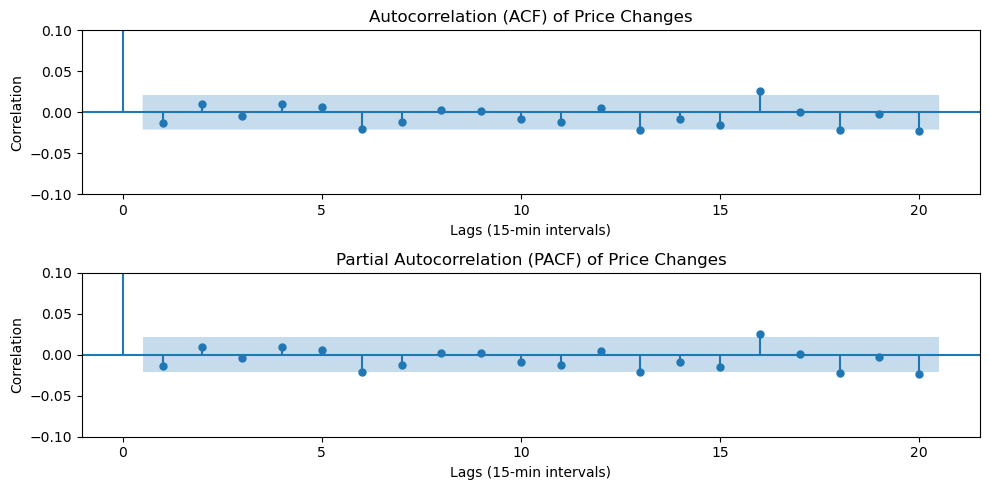

In [71]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Consider price changes for autocorrelation and momentum strategies
# Lags=20 shows 5 hours of 15-minute intervals
price_changes = df_raw["price"].diff().dropna()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 5))

# Autocorrelation Function
plot_acf(price_changes, lags=20, ax=ax1, alpha=0.05, title="Autocorrelation (ACF) of Price Changes")
ax1.set_xlabel("Lags (15-min intervals)")
ax1.set_ylabel("Correlation")
ax1.set_ylim(-0.1, 0.1)

# Partial Autocorrelation Function
plot_pacf(price_changes, lags=20, ax=ax2, title="Partial Autocorrelation (PACF) of Price Changes")
ax2.set_xlabel("Lags (15-min intervals)")
ax2.set_ylabel("Correlation")
ax2.set_ylim(-0.1, 0.1)

plt.tight_layout()
plt.show()

# Backtest Audit

Here, the different mistakes are addressed by severity and fixes are implemented to reevaluate the results.

**Fatal Mistakes:**
* **Look-Ahead Bias:** `rolling(center=True)` calculates the moving average using future prices (up to 2 hours / 8 data points into the future).
* **Execution Logic:** `df["position"] * df["ret"]` assumes trade execution at the exactly when a price change happens -> position must be lagged `.shift(1)`, otherwise time travel is possible
* **In-Sample Overfitting:** optimal threshold is determined over the entire 90-day dataset -> no out-of-sample test.

**Big Mistakes:**
* **No Transaction costs:** strategy assumes ~42=3822/90 intraday trades per day with zero fees.
* **Selection Bias:** `optimize_threshold` loops across 24 different thresholds -> picking the max Sharpe from 24 trials inflates expected performance: expected value of maximum is greater than the expected value of a single trial
* **Buy high, sell low:** buy when prices peak/demand is high assumes trend persistence, but physical grid balancing forces prices to mean-revert
* **Wrong Annualization:** Sharpe ratio is annualized using stock market days ($\sqrt{252}$) instead of continuous 15-minute bars ($\sqrt{35040}$).
* **Negative Returns:** Power prices can potentially go negative -> breaks percentage returns. 

**Smaller Mistakes:**
* **Data Leakage:** Z-score is normalized using the entire 90-day global mean/std instead of a backward-looking rolling window.
* **Intraday Dynamics:** threshold (z > th) is applied across all 96 daily intervals -> signals on regular daily price transitions rather than onyl on true anomalies.
* **Additive vs. Compound Equity Math:** `1.0 + strat_ret.cumsum()` computes cumulative percentage growth additively rather than multiplicatively `(1 + strat_ret).cumprod()`

**Coding:**
* **In-place mutation:** build_features(df) modifies columns directly on the input df


In [58]:
# constant parameters for the analysis
WINDOW = 16  # 16 × 15 min = 4 h local-average window/ 2*center=True
YEARLY_OBS = 4 * 24 * 365
SCALING_ENERGY = np.sqrt(YEARLY_OBS)
SCALING_STOCKS = np.sqrt(252) # convention as in equity markets
COST = 0.15 # EUR/MWh combined spread
TRAIN_SPLIT = 60 * 96
THRESHOLDS = np.arange(0.2, 2.6, 0.1)

# storing results
results = []
equity_curves = {}

In [59]:
def sharpe_ratio(returns, annualize=SCALING_ENERGY):
    """Annualised Sharpe ratio from a return series."""
    r = returns.dropna()
    if len(r) < 2 or r.std() == 0:
        return 0.0
    return r.mean() / r.std() * annualize


def count_switches(positions):
    """Count the number of position changes."""
    return int((positions.diff().abs() > 0).sum())

In [ ]:
def run_stepwise_fixes(
    df,
    # Fatal mistakes
    center_window=True,
    lag_position=False,
    train_test_split=False,
    # Big mistakes
    cost_per_turnover=0.0,
    fixed_threshold=None,
    direction="momentum",
    return_type="pct",
    annualize=SCALING_STOCKS,
    # Smaller mistakes
    global_norm=True,
    normalize_by_time_of_day=False,
    compound_pct_equity=False
):
    """Runs optimization and backtest with any combination of the fixes."""
    df = df.copy()  # Fixes in-place mutation directly -> no impact on performance
    
    # Feature calculation normalized by day time
    if normalize_by_time_of_day:
        df["time_group"] = df["timestamp"].dt.time
        df["moving_avg"] = df.groupby("time_group")["price"].transform(lambda x: x.rolling(14, min_periods=7).mean())
        df["rolling_std"] = df.groupby("time_group")["price"].transform(lambda x: x.rolling(14, min_periods=7).std())
    else:
        min_p = 1 if center_window else WINDOW
        df["moving_avg"] = df["price"].rolling(WINDOW, center=center_window, min_periods=min_p).mean()
        df["rolling_std"] = df["price"].rolling(WINDOW, center=center_window, min_periods=min_p).std()
        
    df["z_score"] = (df["price"] - df["moving_avg"]) / df["rolling_std"]
    
    if global_norm:
        df["z_score"] = (df["z_score"] - df["z_score"].mean()) / df["z_score"].std()

    # train/test subsets if split is enabled
    split_idx = 60 * 96 if train_test_split else len(df)
    train_df = df.iloc[:split_idx].copy()
    test_df = df.iloc[split_idx:].copy() if train_test_split else df.copy()

    # Determine winning threshold: either fixed or grid searched across 24 trials
    if fixed_threshold is not None:
        best_threshold = fixed_threshold
    else:
        best_threshold, best_sharpe = None, -np.inf
        for threshold in THRESHOLDS:
            bt_train = train_df.copy()
            if direction == "momentum":
                bt_train["position"] = np.where(bt_train["z_score"] > threshold, 1.0, np.where(bt_train["z_score"] < -threshold, -1.0, 0.0))
            else:
                bt_train["position"] = np.where(bt_train["z_score"] > threshold, -1.0, np.where(bt_train["z_score"] < -threshold, 1.0, 0.0))
                
            pos = bt_train["position"].shift(1) if lag_position else bt_train["position"]
            raw_ret = bt_train["price"].diff().fillna(0.0) if return_type == "diff" else bt_train["price"].pct_change().replace([np.inf, -np.inf], np.nan).fillna(0.0)
            turnover = pos.diff().abs().fillna(0.0)
            net_ret = (pos * raw_ret) - (turnover * cost_per_turnover)
            
            s = sharpe_ratio(net_ret, annualize=annualize)
            if s > best_sharpe:
                best_threshold, best_sharpe = threshold, s

    # Out-of-Sample or Full Sample
    bt_eval = test_df.copy()
    if direction == "momentum":
        bt_eval["position"] = np.where(bt_eval["z_score"] > best_threshold, 1.0, np.where(bt_eval["z_score"] < -best_threshold, -1.0, 0.0))
    else:
        bt_eval["position"] = np.where(bt_eval["z_score"] > best_threshold, -1.0, np.where(bt_eval["z_score"] < -best_threshold, 1.0, 0.0))
        
    pos_eval = bt_eval["position"].shift(1) if lag_position else bt_eval["position"]
    raw_ret_eval = bt_eval["price"].diff().fillna(0.0) if return_type == "diff" else bt_eval["price"].pct_change().replace([np.inf, -np.inf], np.nan).fillna(0.0)
    turnover_eval = pos_eval.diff().abs().fillna(0.0)
    
    bt_eval["strategy_return"] = (pos_eval * raw_ret_eval) - (turnover_eval * cost_per_turnover)
    
    # Compound vs Additive
    if return_type == "diff":
        bt_eval["equity"] = bt_eval["strategy_return"].cumsum()
    elif compound_pct_equity:
        bt_eval["equity"] = (1.0 + bt_eval["strategy_return"]).cumprod()
    else:
        bt_eval["equity"] = 1.0 + bt_eval["strategy_return"].cumsum()
        
    eval_sharpe = sharpe_ratio(bt_eval["strategy_return"], annualize=annualize)
    return best_threshold, eval_sharpe, bt_eval


# Helper function to store and print metrics for each simulation
def record_step(step_id, description, threshold, sharpe, backtest_df, lag_position=False, is_diff=False):
    total_return = backtest_df["equity"].iloc[-1] if is_diff else (backtest_df["equity"].iloc[-1] - 1.0) * 100
    return_unit = "EUR" if is_diff else "% ret"
    switches = count_switches(backtest_df["position"])
    
    pos_col = backtest_df["position"].shift(1) if lag_position else backtest_df["position"]
    return_periods = backtest_df.loc[pos_col != 0, "strategy_return"]
    hit_rate = (return_periods > 0).mean() if len(return_periods) > 0 else 0.0

    results.append({
        "step": step_id, "fix": fix_description, "sharpe": sharpe, 
        "metric": f"{total_return:.1f} {return_unit}", "threshold": threshold, "switches": switches,
    })
    equity_curves[f"Step {step_id}"] = backtest_df[["timestamp", "equity"]].copy()

    print(
        f"Step {step_id}: {fix_description} — "
        f"threshold={threshold:.2f}, sharpe={sharpe:.2f}, "
        f"return={total_return:.1f} {return_unit}, hit rate={hit_rate * 100:.1f}%, switches={switches}"
    )

In [ ]:
# Step 0: Original strategy
th, s, bt = run_stepwise_fixes(df_raw, center_window=True, lag_position=False, train_test_split=False, cost_per_turnover=0.0, fixed_threshold=None, direction="momentum", return_type="pct", annualize=SCALING_STOCKS, global_norm=True, normalize_by_time_of_day=False, compound_pct_equity=False)
record_step("0", "Original strategy", th, s, bt, lag_position=False, is_diff=False)

# Fatal mistakes:
# Step 1: Look-Ahead Bias #1 (Rolling window)
th, s, bt = run_stepwise_fixes(df_raw, center_window=False, lag_position=False, train_test_split=False, cost_per_turnover=0.0, fixed_threshold=None, direction="momentum", return_type="pct", annualize=SCALING_STOCKS, global_norm=True, normalize_by_time_of_day=False, compound_pct_equity=False)
record_step("1", "Causal window (center=False)", th, s, bt, lag_position=False, is_diff=False)

# Step 2: Look-Ahead Bias #2 (Execution time travel)
th, s, bt = run_stepwise_fixes(df_raw, center_window=False, lag_position=True, train_test_split=False, cost_per_turnover=0.0, fixed_threshold=None, direction="momentum", return_type="pct", annualize=SCALING_STOCKS, global_norm=True, normalize_by_time_of_day=False, compound_pct_equity=False)
record_step("2", "Lag execution)", th, s, bt, lag_position=True, is_diff=False)

# Step 3: In-Sample Overfitting (Out-of-sample evaluation on Days 61-90)
th, s, bt = run_stepwise_fixes(df_raw, center_window=False, lag_position=True, train_test_split=True, cost_per_turnover=0.0, fixed_threshold=None, direction="momentum", return_type="pct", annualize=SCALING_STOCKS, global_norm=True, normalize_by_time_of_day=False, compound_pct_equity=False)
record_step("3", "Out-of-sample evaluation", th, s, bt, lag_position=True, is_diff=False)

# Big mistakes:
# Step 4: No transaction costs
th, s, bt = run_stepwise_fixes(df_raw, center_window=False, lag_position=True, train_test_split=True, cost_per_turnover=0.2, fixed_threshold=None, direction="momentum", return_type="pct", annualize=SCALING_STOCKS, global_norm=True, normalize_by_time_of_day=False, compound_pct_equity=False)
record_step("4", "Subtract some transaction costs", th, s, bt, lag_position=True, is_diff=False)

# Step 5: Multiple testing problem (Fixed threshold=2.0 without grid search)
th, s, bt = run_stepwise_fixes(df_raw, center_window=False, lag_position=True, train_test_split=True, cost_per_turnover=0.2, fixed_threshold=2.0, direction="momentum", return_type="pct", annualize=SCALING_STOCKS, global_norm=True, normalize_by_time_of_day=False, compound_pct_equity=False)
record_step("5", "Fixed threshold (th=2.0) without grid search", th, s, bt, lag_position=True, is_diff=False)

# Step 6: Buy high, sell low
th, s, bt = run_stepwise_fixes(df_raw, center_window=False, lag_position=True, train_test_split=True, cost_per_turnover=0.20, fixed_threshold=2.0, direction="reversion", return_type="pct", annualize=SCALING_STOCKS, global_norm=True, normalize_by_time_of_day=False, compound_pct_equity=False)
record_step("6", "Selection bias (short when z > 2.0)", th, s, bt, lag_position=True, is_diff=False)

# Step 7: Wrong annualization
th, s, bt = run_stepwise_fixes(df_raw, center_window=False, lag_position=True, train_test_split=True, cost_per_turnover=0.20, fixed_threshold=2.0, direction="reversion", return_type="pct", annualize=np.sqrt(35040), global_norm=True, normalize_by_time_of_day=False, compound_pct_equity=False)
record_step("7", "Wrong Annualization", th, s, bt, lag_position=True, is_diff=False)

# Step 8: Absolute PnL (Negative returns)
th, s, bt = run_stepwise_fixes(df_raw, center_window=False, lag_position=True, train_test_split=True, cost_per_turnover=0.20, fixed_threshold=2.0, direction="reversion", return_type="diff", annualize=np.sqrt(35040), global_norm=True, normalize_by_time_of_day=False, compound_pct_equity=False)
record_step("8", "Absolute cash PnL (return_type=diff)", th, s, bt, lag_position=True, is_diff=True)

# Smaller mistakes:
# Step 9: Data leakage (Remove global z-score normalization)
th, s, bt = run_stepwise_fixes(df_raw, center_window=False, lag_position=True, train_test_split=True, cost_per_turnover=0.20, fixed_threshold=2.0, direction="reversion", return_type="diff", annualize=np.sqrt(35040), global_norm=False, normalize_by_time_of_day=False, compound_pct_equity=False)
record_step("9", "Remove global normalization", th, s, bt, lag_position=True, is_diff=True)

# Step 10: Intraday dynamics (Time-of-day interval normalization)
th, s, bt = run_stepwise_fixes(df_raw, center_window=False, lag_position=True, train_test_split=True, cost_per_turnover=0.20, fixed_threshold=2.0, direction="reversion", return_type="diff", annualize=np.sqrt(35040), global_norm=False, normalize_by_time_of_day=True, compound_pct_equity=False)
record_step("10", "Time-of-day normalization", th, s, bt, lag_position=True, is_diff=True)

# Step 11: Additive vs compound math
th, s, bt = run_stepwise_fixes(df_raw, center_window=True, lag_position=False, train_test_split=False, cost_per_turnover=0.0, fixed_threshold=None, direction="momentum", return_type="pct", annualize=SCALING_STOCKS, global_norm=True, normalize_by_time_of_day=False, compound_pct_equity=True)
record_step("11", "True compounding math (cumprod)", th, s, bt, lag_position=False, is_diff=False)

Step 0: Original strategy — threshold=0.40, sharpe=6.14, return=9035.9 % ret, hit rate=68.4%, switches=3822
Step 1: Causal window (center=False) — threshold=1.00, sharpe=7.13, return=8696.7 % ret, hit rate=81.6%, switches=2306
Step 2: Lag execution) — threshold=1.70, sharpe=0.23, return=114.5 % ret, hit rate=50.7%, switches=704
Step 3: Out-of-sample evaluation — threshold=1.70, sharpe=0.16, return=26.8 % ret, hit rate=51.8%, switches=236
Step 4: Subtract some transaction costs — threshold=2.50, sharpe=0.00, return=0.0 % ret, hit rate=0.0%, switches=0
Step 5: Fixed threshold (th=2.0) without grid search — threshold=2.00, sharpe=-2.37, return=-1325.0 % ret, hit rate=7.9%, switches=66
Step 6: Selection bias (short when z > 2.0) — threshold=2.00, sharpe=-2.41, return=-1315.0 % ret, hit rate=2.6%, switches=66
Step 7: Continuous annualization (sqrt(35040)) — threshold=2.00, sharpe=-28.43, return=-1315.0 % ret, hit rate=2.6%, switches=66
Step 8: Absolute cash PnL (return_type=diff) — threshol